# Q2: Unsupervised Learning — Customer Segmentation

## 1. Data Preparation
## 2. Choosing K (Elbow Method)
## 3. K-Means Clustering
## 4. PCA (Dimensionality Reduction)
## 5. Cluster Visualization

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('/content/q2_customers.csv')

# Display basic info
print("Shape:", df.shape)
df.head()

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

Shape: (500, 6)


### Why Scaling is Important:

- K-Means clustering is based on distance (Euclidean distance).
- Features with larger values can dominate the distance calculation.
- Scaling ensures that all features contribute equally to clustering.
- Without scaling, the results of K-Means would be biased toward features with larger magnitudes.

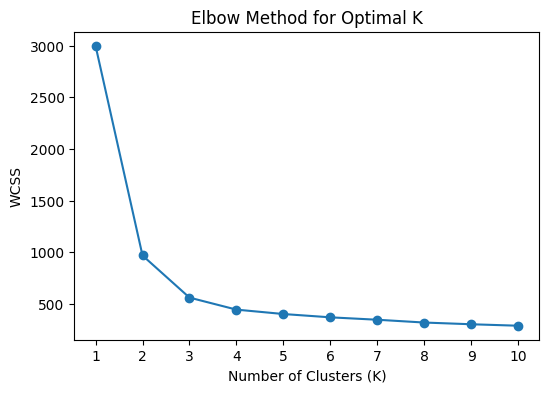

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

# Compute WCSS for K = 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.show()

### Choosing Optimal K:

- The elbow method shows how WCSS decreases as the number of clusters increases.
- There is a sharp decrease in WCSS from K=1 to K=3, indicating that adding clusters significantly improves clustering up to this point.
- After K=3, the rate of decrease slows down considerably, showing diminishing returns.

- The "elbow point" is observed at **K = 3**.

### Conclusion:

- The optimal number of clusters is **K = 3**, as it provides a good balance between minimizing WCSS and avoiding unnecessary model complexity.

In [3]:
from sklearn.cluster import KMeans

# -----------------------------
# Apply K-Means with K=3
# -----------------------------
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to dataframe
df['cluster'] = clusters

# -----------------------------
# Cluster centroids
# -----------------------------
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]  # exclude 'cluster'
)

print("Cluster Centroids:\n")
centroids

Cluster Centroids:



,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


### Cluster Interpretation:

- **Cluster 0 (Young, Frequent Low-Spenders):**
  - Average age is low (~25 years)
  - Low annual spend (~15k)
  - High visit frequency (~14 visits/month)
  - Small basket size (~559)
  - Very recent visits (~9 days)
  - Low number of categories purchased (~2)

  → These customers are **young, highly active shoppers** who visit frequently but spend small amounts each time. They are likely budget-conscious and responsive to small, frequent purchases.

---

- **Cluster 1 (Older, High-Value Infrequent Customers):**
  - Highest age (~57 years)
  - Very high annual spend (~89k)
  - Very low visit frequency (~2.5 visits/month)
  - Very large basket size (~5530)
  - Long gap since last visit (~105 days)
  - High category diversity (~7.5)

  → These customers are **high-value but infrequent buyers**. They make large purchases occasionally and explore multiple product categories. They are likely premium or bulk buyers.

---

- **Cluster 2 (Middle-Aged Moderate Customers):**
  - متوسط age (~40 years)
  - Moderate annual spend (~43k)
  - متوسط visit frequency (~8 visits/month)
  - Medium basket size (~2022)
  - Moderate recency (~35 days)
  - متوسط category diversity (~4.4)

  → These customers represent **balanced, regular shoppers** with moderate spending and engagement. They are consistent and form a stable customer base.

---

### Summary:

- The clustering identifies three distinct customer segments:
  - Frequent low-spenders (Cluster 0)
  - High-value infrequent buyers (Cluster 1)
  - Moderate regular customers (Cluster 2)

- These segments can be used for **targeted marketing strategies**, such as:
  - Discounts and engagement offers for Cluster 0
  - Premium offers and loyalty programs for Cluster 1
  - Retention strategies for Cluster 2

In [4]:
from sklearn.decomposition import PCA

# Apply PCA (2 components)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

# Create DataFrame for PCA results
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])

# -----------------------------
# Explained Variance
# -----------------------------
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# -----------------------------
# Feature Loadings
# -----------------------------
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns[:-1]  # exclude cluster column
)

print("\nFeature Loadings:")
loadings

Explained Variance Ratio:
[0.83560354 0.05568764]

Feature Loadings:


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


### PCA Interpretation:

- The first principal component (PC1) explains **83.56%** of the total variance.
- The second principal component (PC2) explains **5.57%** of the total variance.

- From the loadings:
  - **PC1** is strongly influenced by features such as:
    - annual_spend (0.42)
    - basket_size (0.41)
    - num_categories_purchased (0.41)
    - age (0.41)
  - It also has a negative contribution from visits_per_month (-0.41)

  → This suggests that **PC1 represents overall customer value and spending behavior**, where:
    - Higher values correspond to customers who spend more, buy more items, and purchase across multiple categories.

- **PC2** is dominated by:
  - days_since_last_visit (0.91)

  → This indicates that **PC2 captures customer recency behavior**, i.e., how recently a customer has visited.

### Conclusion:

- PCA effectively reduces the dataset to two dimensions while retaining most of the important information (over 89% variance).
- PC1 captures overall spending and value-related behavior, while PC2 captures recency.
- These components are useful for visualizing and understanding customer segments.

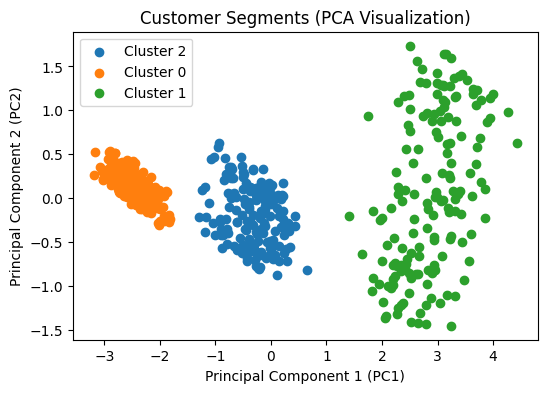

In [5]:
import matplotlib.pyplot as plt

# Combine PCA + cluster labels
pca_df['cluster'] = df['cluster']

# Scatter plot
plt.figure(figsize=(6,4))

for cluster in pca_df['cluster'].unique():
    subset = pca_df[pca_df['cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}')

plt.title('Customer Segments (PCA Visualization)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend()
plt.show()

### Cluster Visualization:

- The scatter plot shows customer segments projected onto the first two principal components (PC1 and PC2).
- The clusters are **clearly well-separated**, indicating that the K-Means algorithm has effectively identified distinct customer groups.

- There is strong separation along **PC1**, which represents overall spending and customer value.
  - Cluster 1 (right side) consists of high-value customers
  - Cluster 0 (left side) represents low-spending frequent customers
  - Cluster 2 (middle) represents moderate customers

- PC2 adds additional variation based on recency (days since last visit), helping further differentiate customers within clusters.

### Conclusion:

- The visualization confirms that the three clusters are **distinct, meaningful, and well-formed**.
- This validates the effectiveness of both PCA and K-Means clustering for customer segmentation.
- These clearly separated clusters can be directly used for targeted marketing strategies.